In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/readme.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/scenarios.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/license.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-MOS0047.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-IKR0401.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-DRR0162.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-CQW0652.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-PSF0133.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-KRL0501.csv
/kaggle/input/datasets/a

In [2]:
import pandas as pd

logon = pd.read_csv(
    "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/logon.csv"
)

print(logon.shape)
logon.head()

(854859, 5)


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon


In [3]:
logon.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        854859 non-null  object
 1   date      854859 non-null  object
 2   user      854859 non-null  object
 3   pc        854859 non-null  object
 4   activity  854859 non-null  object
dtypes: object(5)
memory usage: 32.6+ MB


In [4]:
logon["activity"].value_counts()


activity
Logon     470591
Logoff    384268
Name: count, dtype: int64

In [5]:
logon["user"].nunique()

1000

In [6]:
logon["date"] = pd.to_datetime(logon["date"])

logon["hour"] = logon["date"].dt.hour

logon[["date", "hour"]].head()

,date,hour
0,2010-01-02 06:49:00,6
1,2010-01-02 06:50:00,6
2,2010-01-02 06:53:04,6
3,2010-01-02 07:00:00,7
4,2010-01-02 07:00:00,7


In [7]:
logon["hour"].value_counts().sort_index()

hour
0       4243
1       4530
2       4433
3       4555
4       4600
5       5166
6       6749
7     149697
8     141848
9      51658
10      9495
11     18790
12     30403
13     30813
14     13547
15     39698
16     82514
17     92291
18     84498
19     35382
20     10367
21     18426
22      5932
23      5224
Name: count, dtype: int64

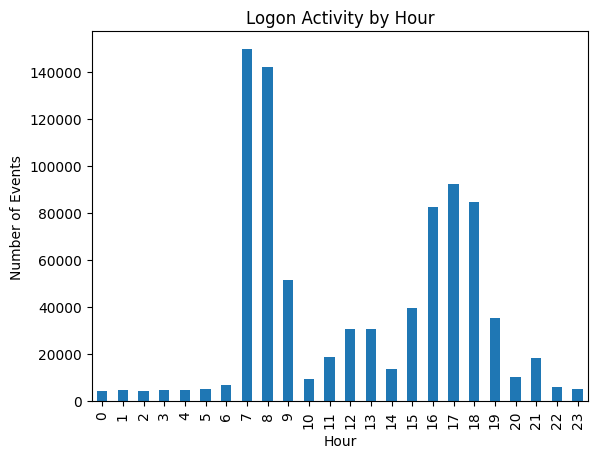

In [8]:
import matplotlib.pyplot as plt

logon["hour"].value_counts().sort_index().plot(kind="bar")

plt.title("Logon Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")

plt.show()

In [9]:
logon["user"].value_counts().head(10)

user
WPR0368    3470
AJF0370    3267
CBB0365    3256
BAL0044    3146
IBB0359    3086
LBC0356    3053
EIS0041    3052
DMG0358    3038
HDS0367    3035
UIR0043    2860
Name: count, dtype: int64

In [10]:
only_logons = logon[logon["activity"] == "Logon"]

only_logons["hour"].value_counts().sort_index()

hour
0       2347
1       2317
2       2206
3       2263
4       2244
5       2408
6       3954
7     146662
8     139629
9      49992
10      7734
11     16702
12     28151
13     28952
14     11838
15      2332
16      1880
17      2271
18      2727
19      2783
20      2810
21      2856
22      3094
23      2439
Name: count, dtype: int64

In [11]:
logon["user"].value_counts().head(10)

user
WPR0368    3470
AJF0370    3267
CBB0365    3256
BAL0044    3146
IBB0359    3086
LBC0356    3053
EIS0041    3052
DMG0358    3038
HDS0367    3035
UIR0043    2860
Name: count, dtype: int64

In [12]:
insiders = pd.read_csv(
    "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv"
)

print(insiders.shape)

insiders.head()

(191, 6)


,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29


In [13]:
insiders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dataset   191 non-null    float64
 1   scenario  191 non-null    int64  
 2   details   191 non-null    object 
 3   user      191 non-null    object 
 4   start     191 non-null    object 
 5   end       191 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.1+ KB


In [14]:
user_features = logon.groupby("user").agg({
    "hour": ["mean", "min", "max"],
    "pc": "nunique",
    "activity": "count"
})

user_features.head()

hour              pc activity
              mean min max nunique    count
user                                       
AAE0190  13.000000   8  18       1      692
AAF0535  12.521341   8  17       1      328
AAF0791  12.500000   8  17       1      692
AAL0706  11.510116   7  17       1      692
AAM0658  14.731441   0  21       1      458

In [15]:
user_features = user_features.reset_index()

user_features.columns = [
    "user",
    "mean_hour",
    "min_hour",
    "max_hour",
    "unique_pcs",
    "event_count"
]

user_features.head()

,user,mean_hour,min_hour,max_hour,unique_pcs,event_count
0,AAE0190,13.000000,8,18,1,692
1,AAF0535,12.521341,8,17,1,328
2,AAF0791,12.500000,8,17,1,692
3,AAL0706,11.510116,7,17,1,692
4,AAM0658,14.731441,0,21,1,458


In [16]:
insider_users = set(insiders["user"])

user_features["is_insider"] = user_features["user"].isin(insider_users)

user_features.head()

,user,mean_hour,min_hour,max_hour,unique_pcs,event_count,is_insider
0,AAE0190,13.000000,8,18,1,692,False
1,AAF0535,12.521341,8,17,1,328,True
2,AAF0791,12.500000,8,17,1,692,False
3,AAL0706,11.510116,7,17,1,692,False
4,AAM0658,14.731441,0,21,1,458,True


In [17]:
user_features["is_insider"].value_counts()

is_insider
False    930
True      70
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = user_features[
    ["mean_hour", "min_hour", "max_hour", "unique_pcs", "event_count"]
]

y = user_features["is_insider"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.98      0.98      0.98       186
        True       0.71      0.71      0.71        14

    accuracy                           0.96       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.96      0.96      0.96       200



In [19]:
device = pd.read_csv(
    "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/device.csv"
)

print(device.shape)

device.head()

(405380, 5)


,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect


In [20]:
device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405380 entries, 0 to 405379
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        405380 non-null  object
 1   date      405380 non-null  object
 2   user      405380 non-null  object
 3   pc        405380 non-null  object
 4   activity  405380 non-null  object
dtypes: object(5)
memory usage: 15.5+ MB


In [21]:
device["activity"].value_counts()

activity
Connect       203339
Disconnect    202041
Name: count, dtype: int64

In [22]:
device_features = device.groupby("user").agg({
    "activity": "count",
    "pc": "nunique"
})

device_features.head()

,activity,pc
user,,
AAF0535,688,1
AAM0658,13,1
ABC0174,1276,1
AHD0848,299,1
AHM0410,782,1


In [23]:
device["activity"].value_counts()

activity
Connect       203339
Disconnect    202041
Name: count, dtype: int64

In [24]:
device_features = device.groupby("user").agg({
    "activity": "count",
    "pc": "nunique"
})

device_features.head()

,activity,pc
user,,
AAF0535,688,1
AAM0658,13,1
ABC0174,1276,1
AHD0848,299,1
AHM0410,782,1


In [25]:
device_features = device_features.reset_index()

device_features.columns = [
    "user",
    "device_events",
    "device_unique_pcs"
]

device_features.head()

,user,device_events,device_unique_pcs
0,AAF0535,688,1
1,AAM0658,13,1
2,ABC0174,1276,1
3,AHD0848,299,1
4,AHM0410,782,1


In [26]:
combined = user_features.merge(
    device_features,
    on="user",
    how="left"
)

combined.head()

,user,mean_hour,min_hour,max_hour,unique_pcs,event_count,is_insider,device_events,device_unique_pcs
0,AAE0190,13.000000,8,18,1,692,False,NaN,NaN
1,AAF0535,12.521341,8,17,1,328,True,688.0,1.0
2,AAF0791,12.500000,8,17,1,692,False,NaN,NaN
3,AAL0706,11.510116,7,17,1,692,False,NaN,NaN
4,AAM0658,14.731441,0,21,1,458,True,13.0,1.0


In [27]:
combined = combined.fillna(0)

In [28]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               1000 non-null   object 
 1   mean_hour          1000 non-null   float64
 2   min_hour           1000 non-null   int32  
 3   max_hour           1000 non-null   int32  
 4   unique_pcs         1000 non-null   int64  
 5   event_count        1000 non-null   int64  
 6   is_insider         1000 non-null   bool   
 7   device_events      1000 non-null   float64
 8   device_unique_pcs  1000 non-null   float64
dtypes: bool(1), float64(3), int32(2), int64(2), object(1)
memory usage: 55.8+ KB


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = combined[
    [
        "mean_hour",
        "min_hour",
        "max_hour",
        "unique_pcs",
        "event_count",
        "device_events",
        "device_unique_pcs"
    ]
]

y = combined["is_insider"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       186
        True       1.00      1.00      1.00        14

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [30]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,event_count,0.359834
5,device_events,0.269958
6,device_unique_pcs,0.162310
3,unique_pcs,0.082474
1,min_hour,0.041960
2,max_hour,0.041736
0,mean_hour,0.041728


In [31]:
combined.groupby("is_insider")[
    ["event_count", "device_events"]
].mean()

,event_count,device_events
is_insider,,
False,865.948387,388.436559
True,707.528571,630.485714


In [32]:
combined["device_events"].describe()

count    1000.000000
mean      405.380000
std      1234.481521
min         0.000000
25%         0.000000
50%         0.000000
75%        14.000000
max      8502.000000
Name: device_events, dtype: float64

In [33]:
combined["device_events"].value_counts().head(20)

device_events
0.0       735
4.0         6
733.0       4
12.0        4
16.0        3
264.0       3
8.0         2
5932.0      2
279.0       2
5955.0      2
22.0        2
780.0       2
38.0        2
833.0       2
14.0        2
1408.0      2
46.0        2
694.0       2
257.0       2
782.0       2
Name: count, dtype: int64

In [34]:
combined.groupby("is_insider")["device_events"].describe()

,count,mean,std,min,25%,50%,75%,max
is_insider,,,,,,,,
False,930.0,388.436559,1251.684625,0.0,0.0,0.0,0.0,8502.0
True,70.0,630.485714,956.510396,4.0,16.0,63.0,979.5,5472.0


In [35]:
file_data = pd.read_csv(
    "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/file.csv"
)

print(file_data.shape)

file_data.head()

file_data.info()

(445581, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445581 entries, 0 to 445580
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        445581 non-null  object
 1   date      445581 non-null  object
 2   user      445581 non-null  object
 3   pc        445581 non-null  object
 4   filename  445581 non-null  object
 5   content   445581 non-null  object
dtypes: object(6)
memory usage: 20.4+ MB


In [36]:
file_data["filename"].head(20)

0     EYPC9Y08.doc
1     N3LTSU3O.pdf
2     D3D3WC9W.doc
3     QCSW62YS.doc
4     AU75JV6U.jpg
5     8ICKVGMO.doc
6     BAO9D5H2.doc
7     1PO60RXU.doc
8     JS09VZOJ.doc
9     MJVNF4DQ.doc
10    LX0I6B1U.pdf
11    WX1IWCEK.txt
12    DPKEXX7J.txt
13    IDJDLCL3.pdf
14    BCG1T122.doc
15    THZZWCOX.doc
16    3QKY90BK.txt
17    EKF5WGJ8.doc
18    STZG8JBH.pdf
19    VX3DF6HY.doc
Name: filename, dtype: object

In [37]:
file_data["content"].head(20)

0     D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1     25-50-44-46-2D carpenters 25 landed strait dis...
2     D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3     D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4                                                 FF-D8
5     D0-CF-11-E0-A1-B1-1A-E1 county one able 1367 h...
6     D0-CF-11-E0-A1-B1-1A-E1 special decided barrag...
7     D0-CF-11-E0-A1-B1-1A-E1 major became many 2010...
8     D0-CF-11-E0-A1-B1-1A-E1 yet chamberlain own co...
9     D0-CF-11-E0-A1-B1-1A-E1 identify 1942 communic...
10    25-50-44-46-2D found british conflict close th...
11    5A-55-4B-41 patients addresses evacuated 5000 ...
12    46-34-56-57 ships approach march well 1990 arr...
13    25-50-44-46-2D 3000 wardeux piece apparent cov...
14    D0-CF-11-E0-A1-B1-1A-E1 securing brigade hbos ...
15    D0-CF-11-E0-A1-B1-1A-E1 lands effectively just...
16    44-33-49-35 though answered morning up worse s...
17    D0-CF-11-E0-A1-B1-1A-E1 protect accidents 

In [38]:
file_data["content"].value_counts().head(20)

content
FF-D8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  22549
D0-CF-11-E0-A1-B1-1A-E1 14 dissolution silent him sole deemed cooperatives reversed 1981 around next college adjacent slowly once convection despite understand beginning length gradual dominated theories caricature received alberto ashamed creatures least neighbourhood ellershaw romano its formally afield still amateur lengths joseph 5100 avenue birthday window degree 168 means transport peak                                                                        

In [39]:
file_data["extension"] = file_data["filename"].str.split(".").str[-1]

file_data["extension"].value_counts()

extension
doc    285897
pdf     87953
txt     23033
jpg     22895
zip     22829
exe      2974
Name: count, dtype: int64

In [40]:
file_features = file_data.groupby("user").agg({
    "filename": ["count", "nunique"]
})

file_features.head()

filename        
           count nunique
user                    
AAF0535      357     357
AAM0658       31      31
ABC0174      589     589
AHD0848      199     199
AHM0410     2198    2198

In [41]:
pd.crosstab(
    file_data["user"],
    file_data["extension"]
).head()

extension,doc,exe,jpg,pdf,txt,zip
user,,,,,,
AAF0535,228,3,23,68,23,12
AAM0658,17,0,1,6,6,1
ABC0174,377,3,24,115,34,36
AHD0848,126,2,10,36,14,11
AHM0410,1416,7,107,441,104,123


In [42]:
file_data["content"].str.contains(
    "patient",
    case=False,
    na=False
).sum()

np.int64(905)

In [43]:
file_data["content"].str.contains(
    "address",
    case=False,
    na=False
).sum()

np.int64(2647)

In [44]:
file_features = file_data.groupby("user").agg(
    total_files=("filename", "count"),
    unique_files=("filename", "nunique")
)

file_features.head()

,total_files,unique_files
user,,
AAF0535,357,357
AAM0658,31,31
ABC0174,589,589
AHD0848,199,199
AHM0410,2198,2198


In [45]:
file_types = pd.crosstab(
    file_data["user"],
    file_data["extension"]
)

file_types.head()

extension,doc,exe,jpg,pdf,txt,zip
user,,,,,,
AAF0535,228,3,23,68,23,12
AAM0658,17,0,1,6,6,1
ABC0174,377,3,24,115,34,36
AHD0848,126,2,10,36,14,11
AHM0410,1416,7,107,441,104,123


In [46]:
file_data["contains_sensitive"] = (
    file_data["content"].str.contains(
        "patient|address",
        case=False,
        na=False
    )
)

In [47]:
sensitive_files = file_data.groupby("user")[
    "contains_sensitive"
].sum()

sensitive_files.head()

user
AAF0535     1
AAM0658     0
ABC0174     8
AHD0848     3
AHM0410    15
Name: contains_sensitive, dtype: int64

In [48]:
file_features = file_features.join(file_types)

file_features["sensitive_files"] = sensitive_files

file_features = file_features.fillna(0)

file_features.head()

,total_files,unique_files,doc,exe,jpg,pdf,txt,zip,sensitive_files
user,,,,,,,,,
AAF0535,357,357,228,3,23,68,23,12,1
AAM0658,31,31,17,0,1,6,6,1,0
ABC0174,589,589,377,3,24,115,34,36,8
AHD0848,199,199,126,2,10,36,14,11,3
AHM0410,2198,2198,1416,7,107,441,104,123,15


In [49]:
file_features.shape

(264, 9)

In [50]:
combined = combined.merge(
    file_features,
    on="user",
    how="left"
)

combined = combined.fillna(0)

combined.head()

,user,mean_hour,min_hour,max_hour,unique_pcs,event_count,is_insider,device_events,device_unique_pcs,total_files,unique_files,doc,exe,jpg,pdf,txt,zip,sensitive_files
0,AAE0190,13.000000,8,18,1,692,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AAF0535,12.521341,8,17,1,328,True,688.0,1.0,357.0,357.0,228.0,3.0,23.0,68.0,23.0,12.0,1.0
2,AAF0791,12.500000,8,17,1,692,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAL0706,11.510116,7,17,1,692,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AAM0658,14.731441,0,21,1,458,True,13.0,1.0,31.0,31.0,17.0,0.0,1.0,6.0,6.0,1.0,0.0


In [51]:
combined.shape

(1000, 18)

In [52]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               1000 non-null   object 
 1   mean_hour          1000 non-null   float64
 2   min_hour           1000 non-null   int32  
 3   max_hour           1000 non-null   int32  
 4   unique_pcs         1000 non-null   int64  
 5   event_count        1000 non-null   int64  
 6   is_insider         1000 non-null   bool   
 7   device_events      1000 non-null   float64
 8   device_unique_pcs  1000 non-null   float64
 9   total_files        1000 non-null   float64
 10  unique_files       1000 non-null   float64
 11  doc                1000 non-null   float64
 12  exe                1000 non-null   float64
 13  jpg                1000 non-null   float64
 14  pdf                1000 non-null   float64
 15  txt                1000 non-null   float64
 16  zip                1000 n

In [53]:
X = combined.drop(
    columns=["user", "is_insider"]
)

y = combined["is_insider"]

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.99      1.00      1.00       186
        True       1.00      0.93      0.96        14

    accuracy                           0.99       200
   macro avg       1.00      0.96      0.98       200
weighted avg       1.00      0.99      0.99       200



In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,event_count,0.224993
5,device_events,0.127713
7,total_files,0.103164
8,unique_files,0.098109
6,device_unique_pcs,0.077395
12,pdf,0.069123
9,doc,0.066315
3,unique_pcs,0.048088
14,zip,0.042354
11,jpg,0.041511


In [56]:
import joblib

joblib.dump(model, "medleak_model.pkl")

['medleak_model.pkl']

In [57]:
import os

print(os.listdir("/kaggle/working"))

['medleak_model.pkl', '__notebook__.ipynb']
